# Student Performance Analysis Using Data Science

The objective of this project is to analyze how different factors such as study hours, attendance, sleep duration, family support, internet access, and extracurricular activities affect student academic performance. The project aims to identify the factors that have the strongest impact on student marks using data analysis and visualization techniques.


## Target Variable

This is what you want to analyze or predict.

Example:

1)Final Marks
2)Percentage
3)Grade
4)Pass/Fail

For your project:Final Marks / Score

### Features (Input Variables)

Example features:

1)Study Hours,
2)Attendance,
3)Sleep Hours,
4)Family Support,
5)Previous Scores,
6)Internet Access,
7)Stress Level,
8)Extracurricular Activities.

#### Project Objective

Example:

1)Find which factors affect marks the most.

2)Identify positive and negative correlations.

3)Predict marks using Linear Regression (optional).

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("dataset.csv")

In [6]:
df.head() #To check the first 5 rows.

,Student_ID,Gender,Age,Study_Hours,Attendance_Percentage,Sleep_Hours,Family_Support,Internet_Access,Extracurricular_Activities,Stress_Level,Previous_Scores,Final_Score
0,1528,FEMALE,17.0,10.0,85.0,5.0,No,No,No,Medium,63.0,66.0
1,1360,FEMALE,21.0,12.0,75.0,10.0,None,yes,No,low,83.0,78.0
2,1448,FEMALE,-1.0,18.0,NaN,9.0,None,None,Yes,low,49.0,NaN
3,1032,Female,22.0,4.0,90.0,7.0,NO,yes,NaN,low,34.0,69.0
4,1622,FEMALE,35.0,2.0,40.0,5.0,Y,no,No,NaN,37.0,-5.0


In [8]:
df.tail() #To check the last 5 rows

,Student_ID,Gender,Age,Study_Hours,Attendance_Percentage,Sleep_Hours,Family_Support,Internet_Access,Extracurricular_Activities,Stress_Level,Previous_Scores,Final_Score
1020,1701,NaN,17.0,8.0,95.0,5.0,Yes,no,yes,HIGH,93.0,57.0
1021,1072,NaN,19.0,3.0,55.0,7.0,Y,yes,yes,low,73.0,53.0
1022,1107,male,19.0,9.0,50.0,5.0,yes,Y,yes,low,85.0,100.0
1023,1271,male,18.0,9.0,80.0,NaN,yes,No,yes,High,52.0,44.0
1024,1861,FEMALE,21.0,1.0,110.0,3.0,yes,no,No,Low,49.0,88.0


In [11]:
df.shape # to check the rows and columns of the dataset. means checking the shape of the dataset

(1025, 12)

In [13]:
df.columns #checking which columns are present in the dataset. 

Index(['Student_ID', 'Gender', 'Age', 'Study_Hours', 'Attendance_Percentage',
       'Sleep_Hours', 'Family_Support', 'Internet_Access',
       'Extracurricular_Activities', 'Stress_Level', 'Previous_Scores',
       'Final_Score'],
      dtype='object')

In [17]:
df.info # it gives the concise structure of the dataframe.

<bound method DataFrame.info of       Student_ID   Gender   Age  Study_Hours  Attendance_Percentage  \
0           1528  FEMALE   17.0         10.0                   85.0   
1           1360  FEMALE   21.0         12.0                   75.0   
2           1448  FEMALE   -1.0         18.0                    NaN   
3           1032  Female   22.0          4.0                   90.0   
4           1622  FEMALE   35.0          2.0                   40.0   
...          ...      ...   ...          ...                    ...   
1020        1701      NaN  17.0          8.0                   95.0   
1021        1072      NaN  19.0          3.0                   55.0   
1022        1107    male   19.0          9.0                   50.0   
1023        1271    male   18.0          9.0                   80.0   
1024        1861   FEMALE  21.0          1.0                  110.0   

      Sleep_Hours Family_Support Internet_Access Extracurricular_Activities  \
0             5.0            No     

In [20]:
df.describe() #statistical summary

,Student_ID,Age,Study_Hours,Attendance_Percentage,Sleep_Hours,Previous_Scores,Final_Score
count,1025.000000,915.000000,954.000000,955.000000,916.000000,1011.000000,1010.000000
mean,1502.256585,18.618579,7.523061,80.345550,6.009825,64.187933,68.060396
std,288.389594,9.221555,4.767632,28.041149,2.596111,23.839652,22.160048
min,1001.000000,-1.000000,1.000000,40.000000,2.000000,-10.000000,-5.000000
25%,1253.000000,17.000000,4.000000,60.000000,4.000000,46.000000,51.000000
50%,1505.000000,19.000000,7.000000,75.000000,6.000000,63.000000,67.000000
75%,1751.000000,21.000000,10.000000,95.000000,8.000000,83.000000,86.000000
max,2000.000000,35.000000,18.000000,150.000000,10.000000,150.000000,120.000000


# Now we start with the data cleaning phase

### A)check null values

In [24]:
df.isnull().sum()

Student_ID                      0
Gender                        146
Age                           110
Study_Hours                    71
Attendance_Percentage          70
Sleep_Hours                   109
Family_Support                177
Internet_Access               181
Extracurricular_Activities    258
Stress_Level                  164
Previous_Scores                14
Final_Score                    15
dtype: int64

### B)Fixing the null values

In [31]:
#this is the numerical data in which we fix the null values by replaceing the null values with their median
numerical_cols = [
    "Age",
    "Study_Hours",
    "Attendance_Percentage",
    "Sleep_Hours",
    "Previous_Scores",
    "Final_Score"
]

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

In [33]:
#Now we can fix the categorical values. by replacing with their modes,means we can replace the null values with their most frequent values
categorical_cols =[
    "Gender",
    "Family_Support",
    "Internet_Access",
    "Extracurricular_Activities",
    "Stress_Level"
]

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [34]:
#now verifying that there is any null values or not.
df.isnull().sum()

Student_ID                    0
Gender                        0
Age                           0
Study_Hours                   0
Attendance_Percentage         0
Sleep_Hours                   0
Family_Support                0
Internet_Access               0
Extracurricular_Activities    0
Stress_Level                  0
Previous_Scores               0
Final_Score                   0
dtype: int64

### C)Now we check the Duplicate Values

In [36]:
df.duplicated().sum()

np.int64(20)

### D)Now we remove the all duplicate values

In [37]:
df= df.drop_duplicates()

In [38]:
#Now we verfiy that there is any duplicate value or not
df.duplicated().sum()

np.int64(0)

In [39]:
#The all duplicate values are cleared

### E)Now we make the text in the standard form

In [42]:
text_cols = [
 "Gender",
    "Family_Support",
    "Internet_Access",
    "Extracurricular_Activities",
    "Stress_Level"
    
]

for col in text_cols:
    df.loc[:, col] = df[col].str.strip().str.lower()

In [43]:
for col in text_cols:
    print(df[col].unique())

['female' 'none' 'male']
['no' 'none' 'y' 'yes']
['no' 'yes' 'none' 'y']
['no' 'yes']
['medium' 'low' 'high']


In [45]:
df.head()

,Student_ID,Gender,Age,Study_Hours,Attendance_Percentage,Sleep_Hours,Family_Support,Internet_Access,Extracurricular_Activities,Stress_Level,Previous_Scores,Final_Score
0,1528,female,17.0,10.0,85.0,5.0,no,no,no,medium,63.0,66.0
1,1360,female,21.0,12.0,75.0,10.0,none,yes,no,low,83.0,78.0
2,1448,female,-1.0,18.0,75.0,9.0,none,none,yes,low,49.0,67.0
3,1032,female,22.0,4.0,90.0,7.0,no,yes,no,low,34.0,69.0
4,1622,female,35.0,2.0,40.0,5.0,y,no,no,medium,37.0,-5.0


In [46]:
df["Family_Support"] = df["Family_Support"].replace({
    "y": "yes",
    "none": "no"
})

C:\Users\Atharv\AppData\Local\Temp\ipykernel_3896\407101805.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Family_Support"] = df["Family_Support"].replace({


In [47]:
df["Internet_Access"] = df["Internet_Access"].replace({
    "y": "yes",
    "none": "no"
})

C:\Users\Atharv\AppData\Local\Temp\ipykernel_3896\1765378903.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Internet_Access"] = df["Internet_Access"].replace({


In [48]:
print(df["Family_Support"].unique())
print(df["Internet_Access"].unique())

['no' 'yes']
['no' 'yes']


In [49]:
print(df["Internet_Access"].unique())

['no' 'yes']


In [50]:
df.tail()

,Student_ID,Gender,Age,Study_Hours,Attendance_Percentage,Sleep_Hours,Family_Support,Internet_Access,Extracurricular_Activities,Stress_Level,Previous_Scores,Final_Score
1020,1701,male,17.0,8.0,95.0,5.0,yes,no,yes,high,93.0,57.0
1021,1072,male,19.0,3.0,55.0,7.0,yes,yes,yes,low,73.0,53.0
1022,1107,male,19.0,9.0,50.0,5.0,yes,yes,yes,low,85.0,100.0
1023,1271,male,18.0,9.0,80.0,6.0,yes,no,yes,high,52.0,44.0
1024,1861,female,21.0,1.0,110.0,3.0,yes,no,no,low,49.0,88.0


In [51]:
#Now the all values are converted in the standard form.

### F)The current task is. Handling of the outliners.

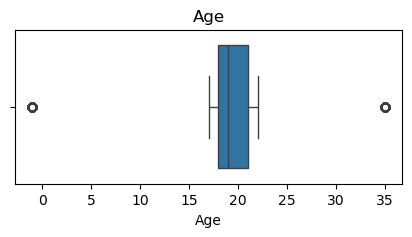

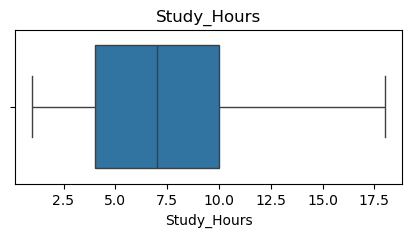

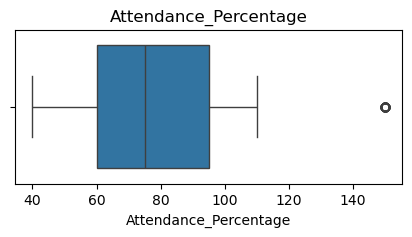

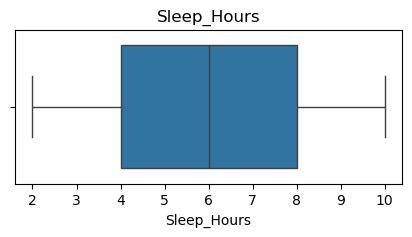

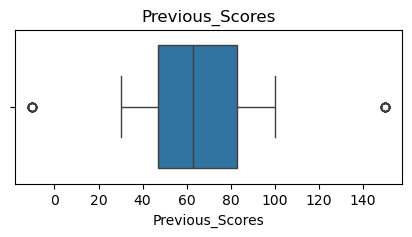

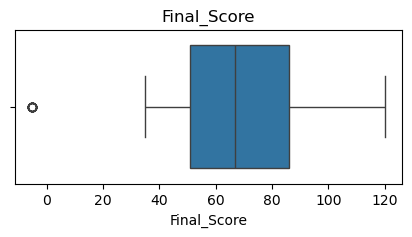

In [52]:
# Step1 => First we have to visualize the outliners using the boxplot

numerical_cols = [
    "Age",
    "Study_Hours",
    "Attendance_Percentage",
    "Sleep_Hours",
    "Previous_Scores",
    "Final_Score"
]

for col in numerical_cols:
    plt.figure(figsize = (5,2))
    sns.boxplot(x = df[col])
    plt.title(col)
    plt.show()

In [53]:
print(df.shape)

(1005, 12)


In [54]:
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 -Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df = df[ (df[col]>=lower_limit) & (df[col]<=upper_limit)]

In [55]:
print(df.shape)

(694, 12)


In [57]:
# now see that the outliners are removed. now we can verify using the boxplot

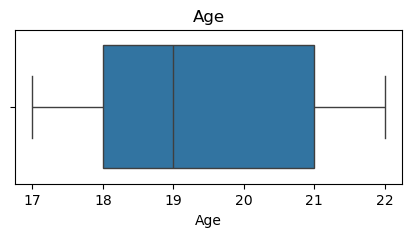

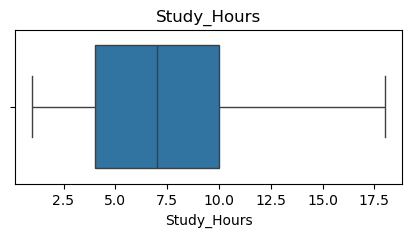

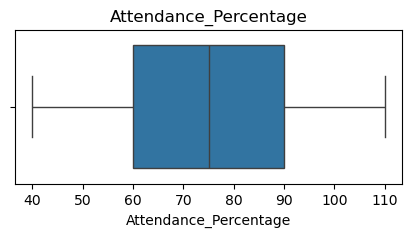

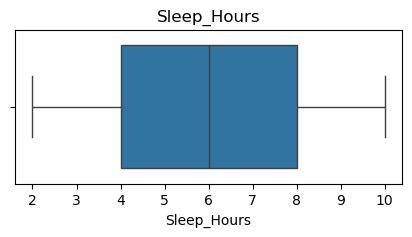

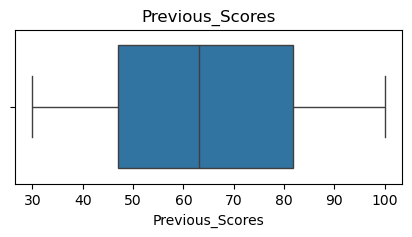

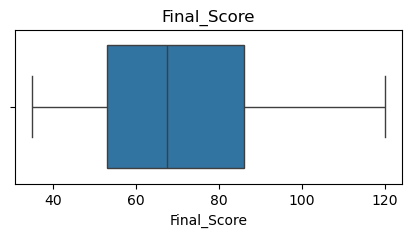

In [58]:
numerical_cols = [
    "Age",
    "Study_Hours",
    "Attendance_Percentage",
    "Sleep_Hours",
    "Previous_Scores",
    "Final_Score"
]

for col in numerical_cols:
    plt.figure(figsize = (5,2))
    sns.boxplot(x = df[col])
    plt.title(col)
    plt.show()

In [59]:
df = df[df["Attendance_Percentage"] <= 100]

df = df[df["Final_Score"] <= 100]
df = df[df["Final_Score"] >= 0]

df = df[df["Previous_Scores"] <= 100]
df = df[df["Previous_Scores"] >= 0]

df = df[df["Age"] > 0]

In [60]:
df.describe()

,Student_ID,Age,Study_Hours,Attendance_Percentage,Sleep_Hours,Previous_Scores,Final_Score
count,642.000000,642.000000,642.000000,642.000000,642.000000,642.000000,642.000000
mean,1505.532710,19.406542,7.364486,72.056075,5.990654,63.730530,68.897196
std,291.164373,1.629914,4.533238,17.817150,2.494282,20.200029,18.605319
min,1001.000000,17.000000,1.000000,40.000000,2.000000,30.000000,35.000000
25%,1249.250000,18.000000,4.000000,55.000000,4.000000,46.250000,53.000000
50%,1519.000000,19.000000,7.000000,75.000000,6.000000,63.000000,67.500000
75%,1751.250000,21.000000,10.000000,85.000000,8.000000,82.000000,85.000000
max,2000.000000,22.000000,18.000000,100.000000,10.000000,100.000000,100.000000


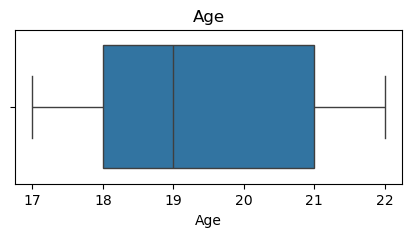

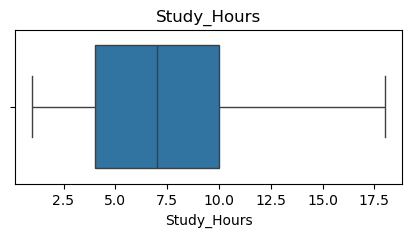

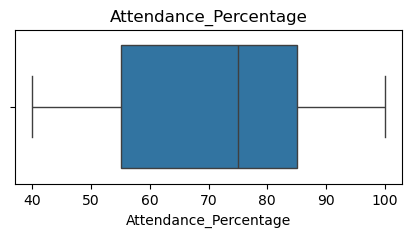

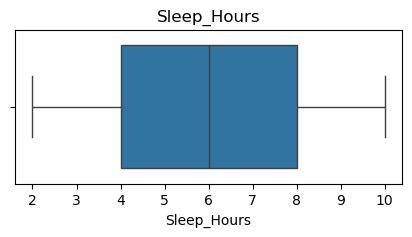

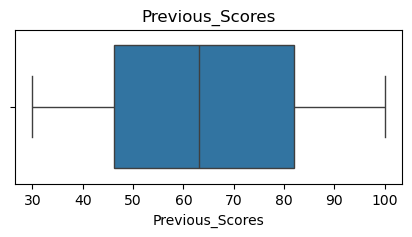

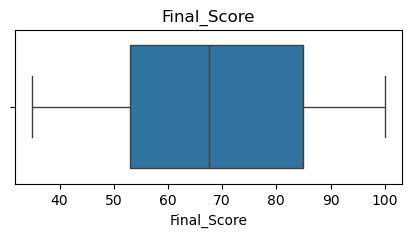

In [61]:
for col in numerical_cols:
    plt.figure(figsize=(5,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

# Now we start with the Exploratory Data Analysis(EDA).

### Task 1 → Study Hours vs Final Score

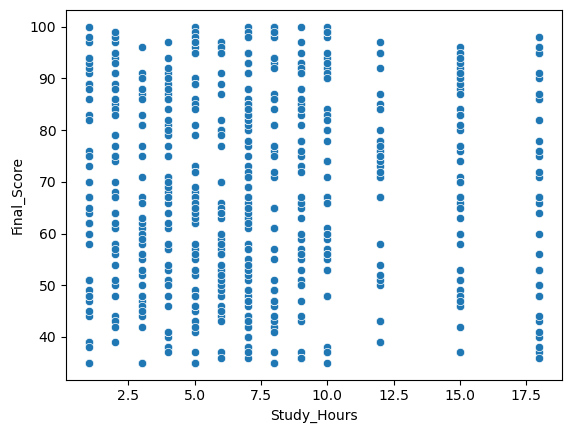

In [62]:
sns.scatterplot(x = "Study_Hours", y = "Final_Score", data =df)
plt.show()

### Task 2 → Attendance vs Final Score

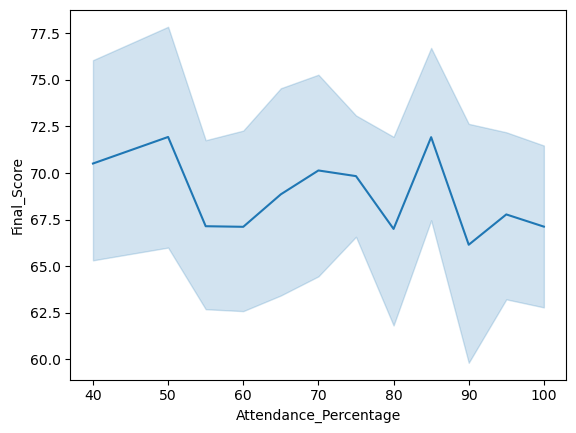

In [64]:
sns.lineplot(x="Attendance_Percentage", y="Final_Score", data=df)
plt.show()

### Task 3 → Family Support Impact

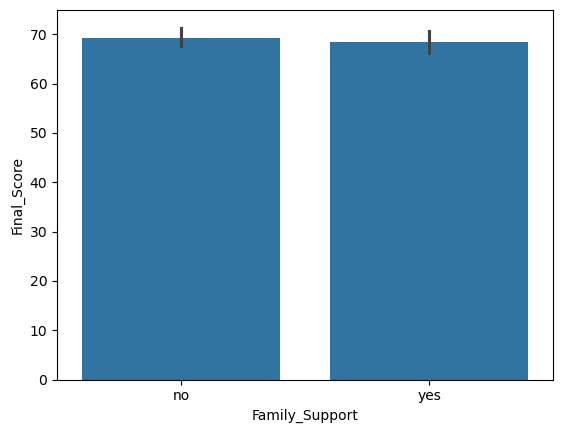

In [65]:
sns.barplot(x="Family_Support", y="Final_Score", data=df)
plt.show()

### Task 4 → Correlation Matrix

<Axes: >

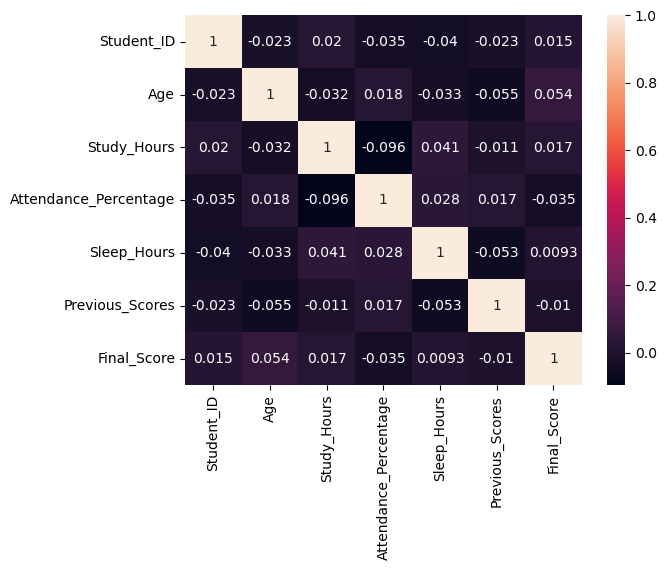

In [66]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

# Now we Start With the Machine Learning.

In [67]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error

### STEP 1 → Convert Text into Numbers

In [68]:
label_encoder = LabelEncoder()

categorical_cols = [
    "Gender",
    "Family_Support",
    "Internet_Access",
    "Extracurricular_Activities",
    "Stress_Level"
]

for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

In [69]:
#Because ML models cannot understand:yes,no,male,female

### STEP 2 → Define Input (X) and Output (y)

In [71]:
""" 
Input columns = features.

Output column = target variable.
"""

' \nInput columns = features.\n\nOutput column = target variable.\n'

In [72]:
X = df.drop("Final_Score", axis=1)
y = df["Final_Score"]

### STEP 3 → Split Data

In [73]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### STEP 4 → Create Model

In [74]:
model = LinearRegression()

### STEP 5 → Train Model

In [75]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [78]:


student_id = int(input("Enter Student ID: "))

gender = input("Enter Gender (male/female): ").lower()

age = int(input("Enter Age: "))

study_hours = float(input("Enter Study Hours: "))

attendance = float(input("Enter Attendance Percentage: "))

sleep_hours = float(input("Enter Sleep Hours: "))

family_support = input("Family Support (yes/no): ").lower()

internet_access = input("Internet Access (yes/no): ").lower()

extra_activities = input("Extracurricular Activities (yes/no): ").lower()

stress_level = input("Stress Level (low/medium/high): ").lower()

previous_scores = float(input("Enter Previous Scores: "))


gender = 1 if gender == "male" else 0

family_support = 1 if family_support == "yes" else 0

internet_access = 1 if internet_access == "yes" else 0

extra_activities = 1 if extra_activities == "yes" else 0

stress_mapping = {
    "low": 0,
    "medium": 1,
    "high": 2
}

stress_level = stress_mapping[stress_level]


new_student = pd.DataFrame([[
    student_id,
    gender,
    age,
    study_hours,
    attendance,
    sleep_hours,
    family_support,
    internet_access,
    extra_activities,
    stress_level,
    previous_scores
]], columns=X.columns)


prediction = model.predict(new_student)

predicted_score = round(prediction[0], 2)

print("\nPredicted Final Score:", predicted_score)


actual_score = float(input("\nEnter Actual Final Score: "))


difference = abs(actual_score - predicted_score)

print("\n========== RESULT ==========")

print("Predicted Score :", predicted_score)

print("Actual Score    :", actual_score)

print("Difference/Error:", round(difference, 2))


if difference <= 5:
    print("Model Prediction is VERY CLOSE")

elif difference <= 10:
    print("Model Prediction is ACCEPTABLE")

else:
    print("Model Prediction has HIGH ERROR")

Enter Student ID:  42
Enter Gender (male/female):  male
Enter Age:  20
Enter Study Hours:  6
Enter Attendance Percentage:  94
Enter Sleep Hours:  8
Family Support (yes/no):  yes
Internet Access (yes/no):  yes
Extracurricular Activities (yes/no):  yes
Stress Level (low/medium/high):  low
Enter Previous Scores:  86



Predicted Final Score: 63.55



Enter Actual Final Score:  64



========== RESULT ==========
Predicted Score : 63.55
Actual Score    : 64.0
Difference/Error: 0.45
Model Prediction is VERY CLOSE
